## Countries life expectancy

https://www.kaggle.com/datasets/saurabhbadole/life-expectancy-based-on-geographic-locations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

## Exploratory data analysis

In [105]:
data = pd.read_csv("../datasets/LifeExpectancy.csv")
data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,Zimbabwe,2004,Developing,44.3,723,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2924,Zimbabwe,2003,Developing,44.5,715,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2925,Zimbabwe,2002,Developing,44.8,73,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2926,Zimbabwe,2001,Developing,45.3,686,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [106]:
data["Country"].value_counts().describe()

count    183.0
mean      16.0
std        0.0
min       16.0
25%       16.0
50%       16.0
75%       16.0
max       16.0
Name: count, dtype: float64

In [107]:
data.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2928.00000,2928.000000,2928.000000,2928.000000,2735.000000,2928.000000,2375.000000,2928.000000,2896.000000,2928.000000,2909.000000,2702.000000,2909.000000,2928.000000,2485.000000,2.284000e+03,2896.000000,2896.000000,2768.000000,2768.000000
mean,2007.50000,69.224932,164.796448,30.407445,4.614856,740.321185,80.960842,2427.855874,38.235394,42.179303,82.548298,5.930163,82.321416,1.747712,7494.210719,1.276454e+07,4.850622,4.881423,0.627419,11.999639
std,4.61056,9.523867,124.292079,118.114450,4.050749,1990.930605,25.018337,11485.970937,19.959590,160.700547,23.416674,2.483273,23.706644,5.085542,14282.251492,6.103765e+07,4.420829,4.509609,0.210978,3.346440
min,2000.00000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2003.75000,63.100000,74.000000,0.000000,0.905000,4.853964,77.000000,0.000000,19.300000,0.000000,78.000000,4.260000,78.000000,0.100000,463.852618,1.966738e+05,1.600000,1.575000,0.493000,10.100000
50%,2007.50000,72.100000,144.000000,3.000000,3.770000,65.611455,92.000000,17.000000,43.350000,4.000000,93.000000,5.750000,93.000000,0.100000,1764.973870,1.391756e+06,3.300000,3.400000,0.677000,12.300000
75%,2011.25000,75.700000,228.000000,22.000000,7.715000,442.614322,97.000000,362.250000,56.100000,28.000000,97.000000,7.490000,97.000000,0.800000,5932.899677,7.426746e+06,7.200000,7.200000,0.779250,14.300000
max,2015.00000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,77.600000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [108]:
#data = data.drop(columns=["Country", "Status"])
data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,Zimbabwe,2004,Developing,44.3,723,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2924,Zimbabwe,2003,Developing,44.5,715,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2925,Zimbabwe,2002,Developing,44.8,73,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2926,Zimbabwe,2001,Developing,45.3,686,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [109]:
data.isna().sum(axis = 1)

0       0
1       0
2       0
3       0
4       0
       ..
2923    0
2924    0
2925    0
2926    0
2927    0
Length: 2928, dtype: int64

In [110]:
data = data[~data.Country.isin(["South Sudan","Democratic People's Republic of Korea", "Somalia", "Sudan"])].reset_index(drop=True)
data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,Zimbabwe,2004,Developing,44.3,723,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2860,Zimbabwe,2003,Developing,44.5,715,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2861,Zimbabwe,2002,Developing,44.8,73,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2862,Zimbabwe,2001,Developing,45.3,686,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [111]:
data = data.dropna()
data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,Zimbabwe,2004,Developing,44.3,723,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2860,Zimbabwe,2003,Developing,44.5,715,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2861,Zimbabwe,2002,Developing,44.8,73,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2862,Zimbabwe,2001,Developing,45.3,686,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


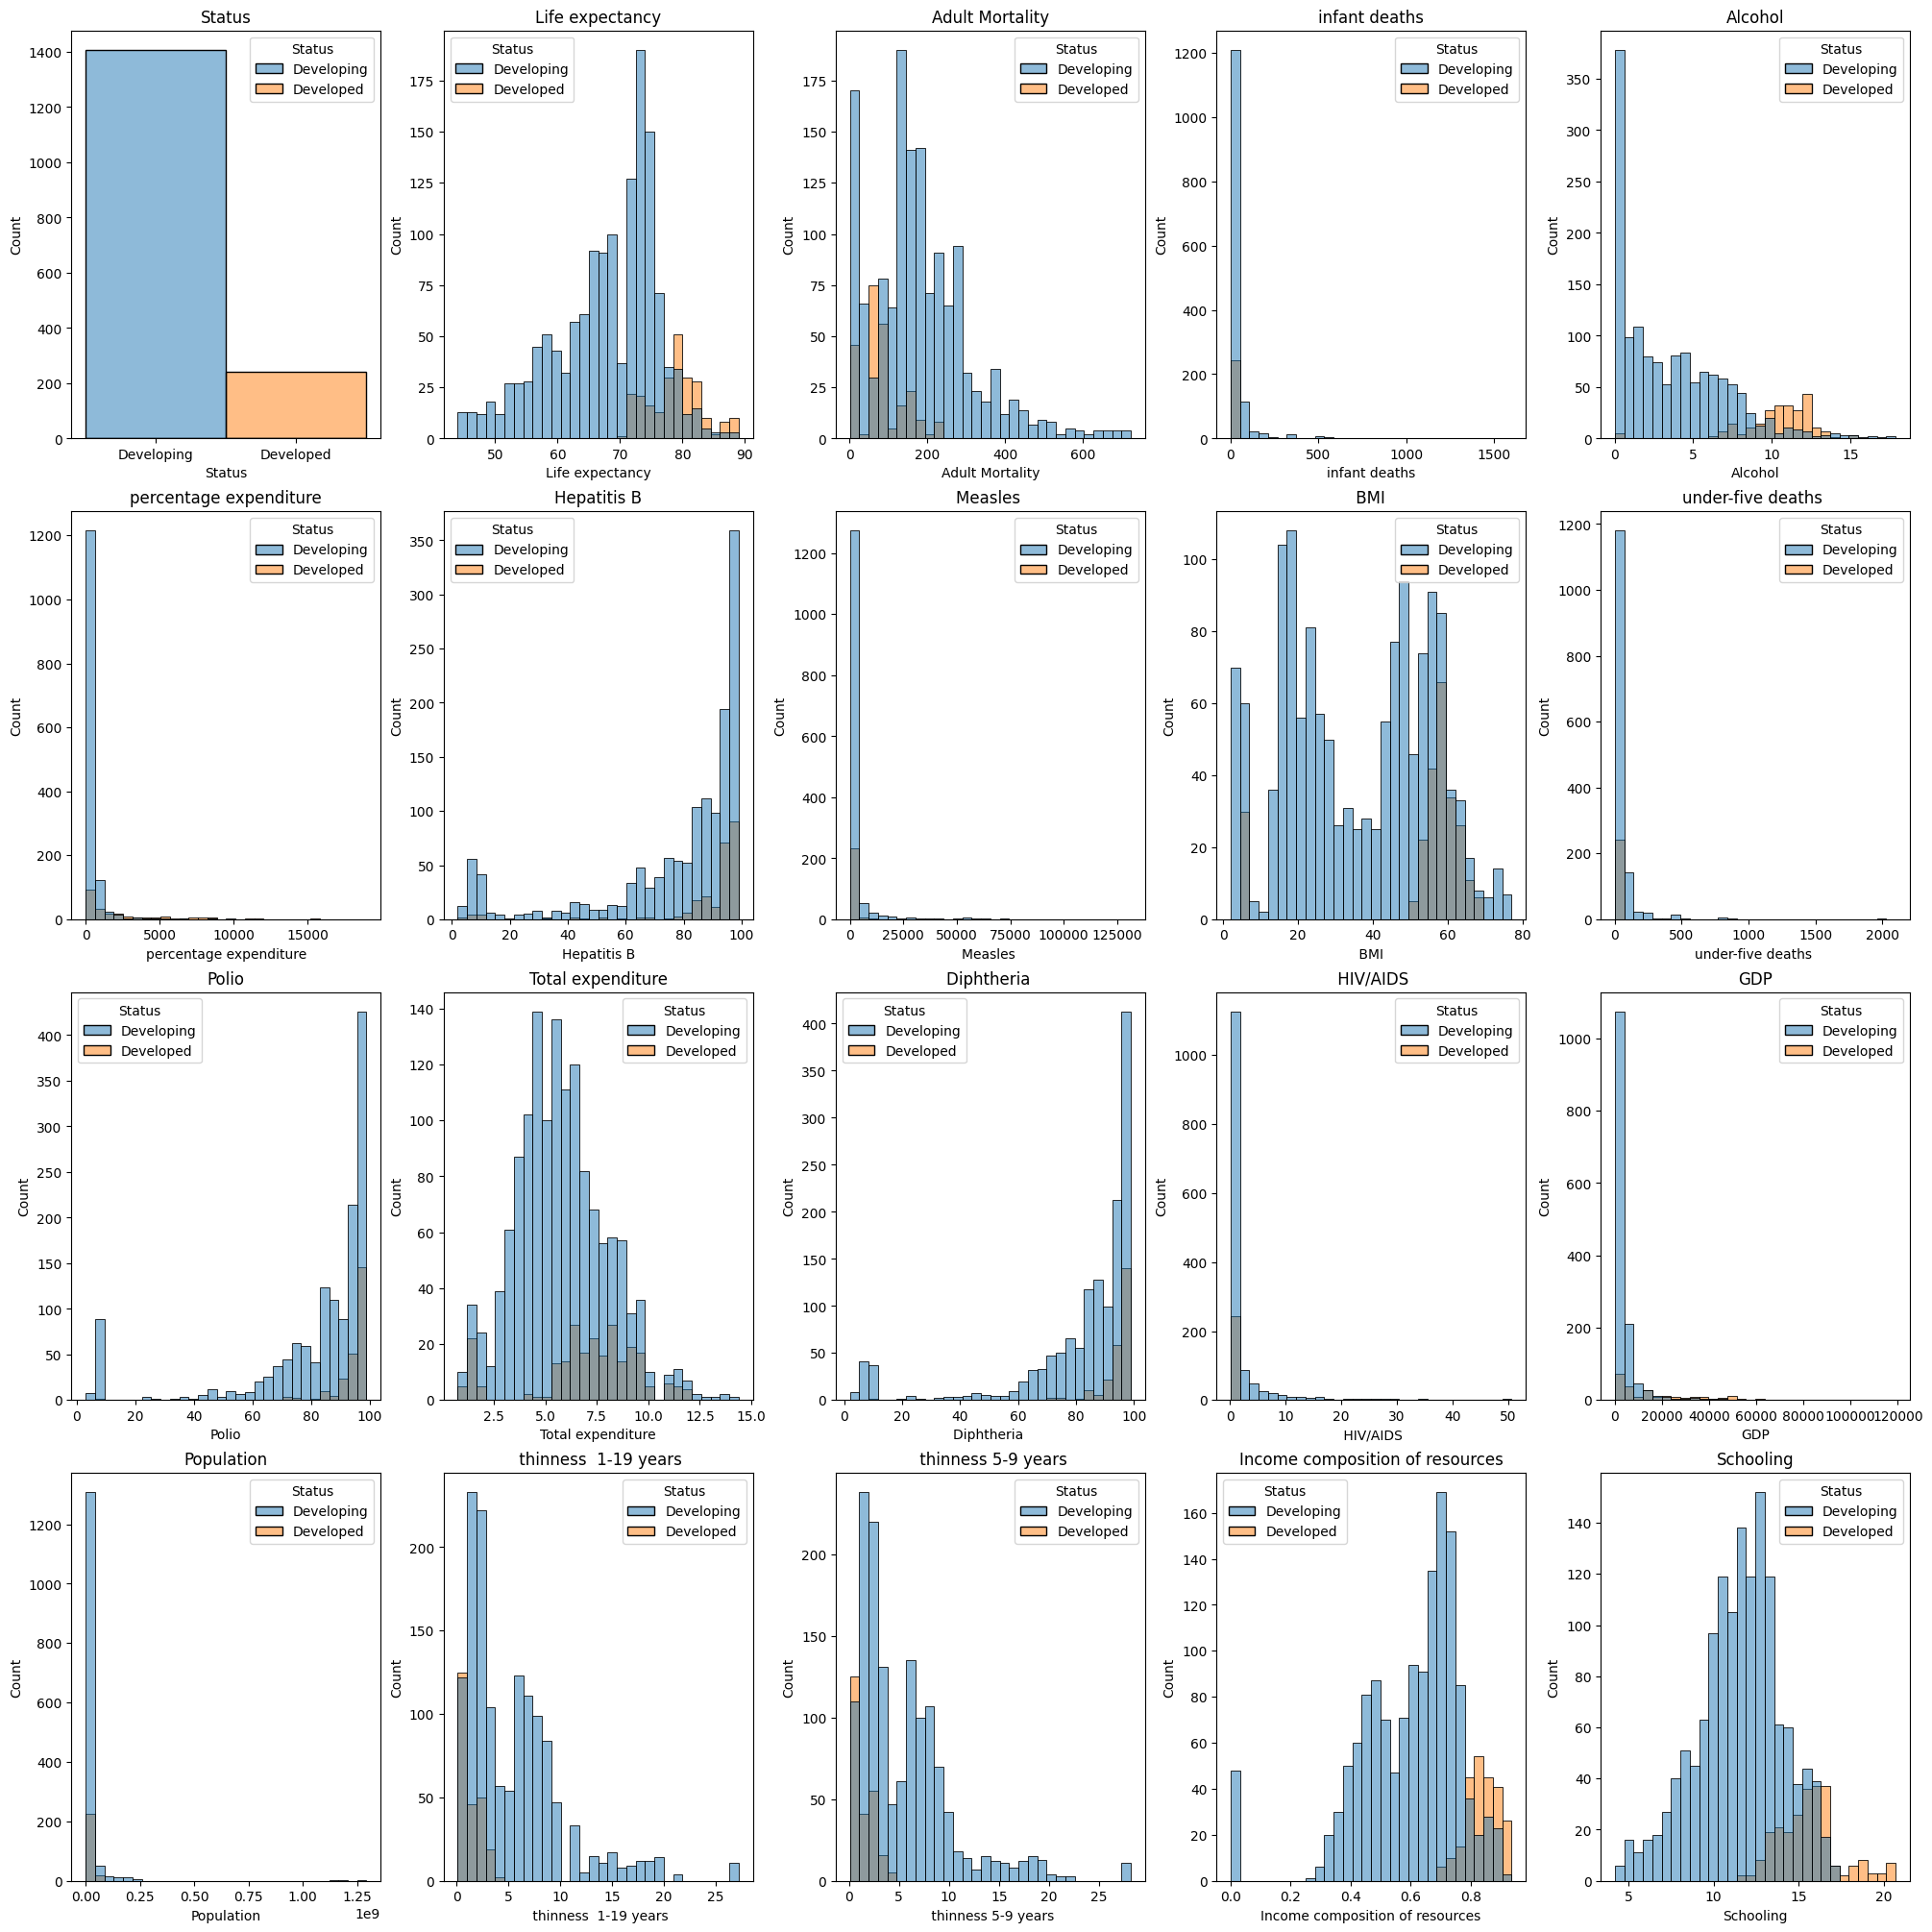

In [112]:
fig, axes = plt.subplots(4, 5, figsize=(20, 20), constrained_layout=True)
columns_to_plot = [a for a in data.columns if a not in ["Country", "Year"]]
for index, column in enumerate(columns_to_plot):
    sns.histplot(data, x = column, hue = data["Status"], bins=30, ax=axes[index//5, index%5])
    axes[index//5, index%5].set_title(column)
plt.show()

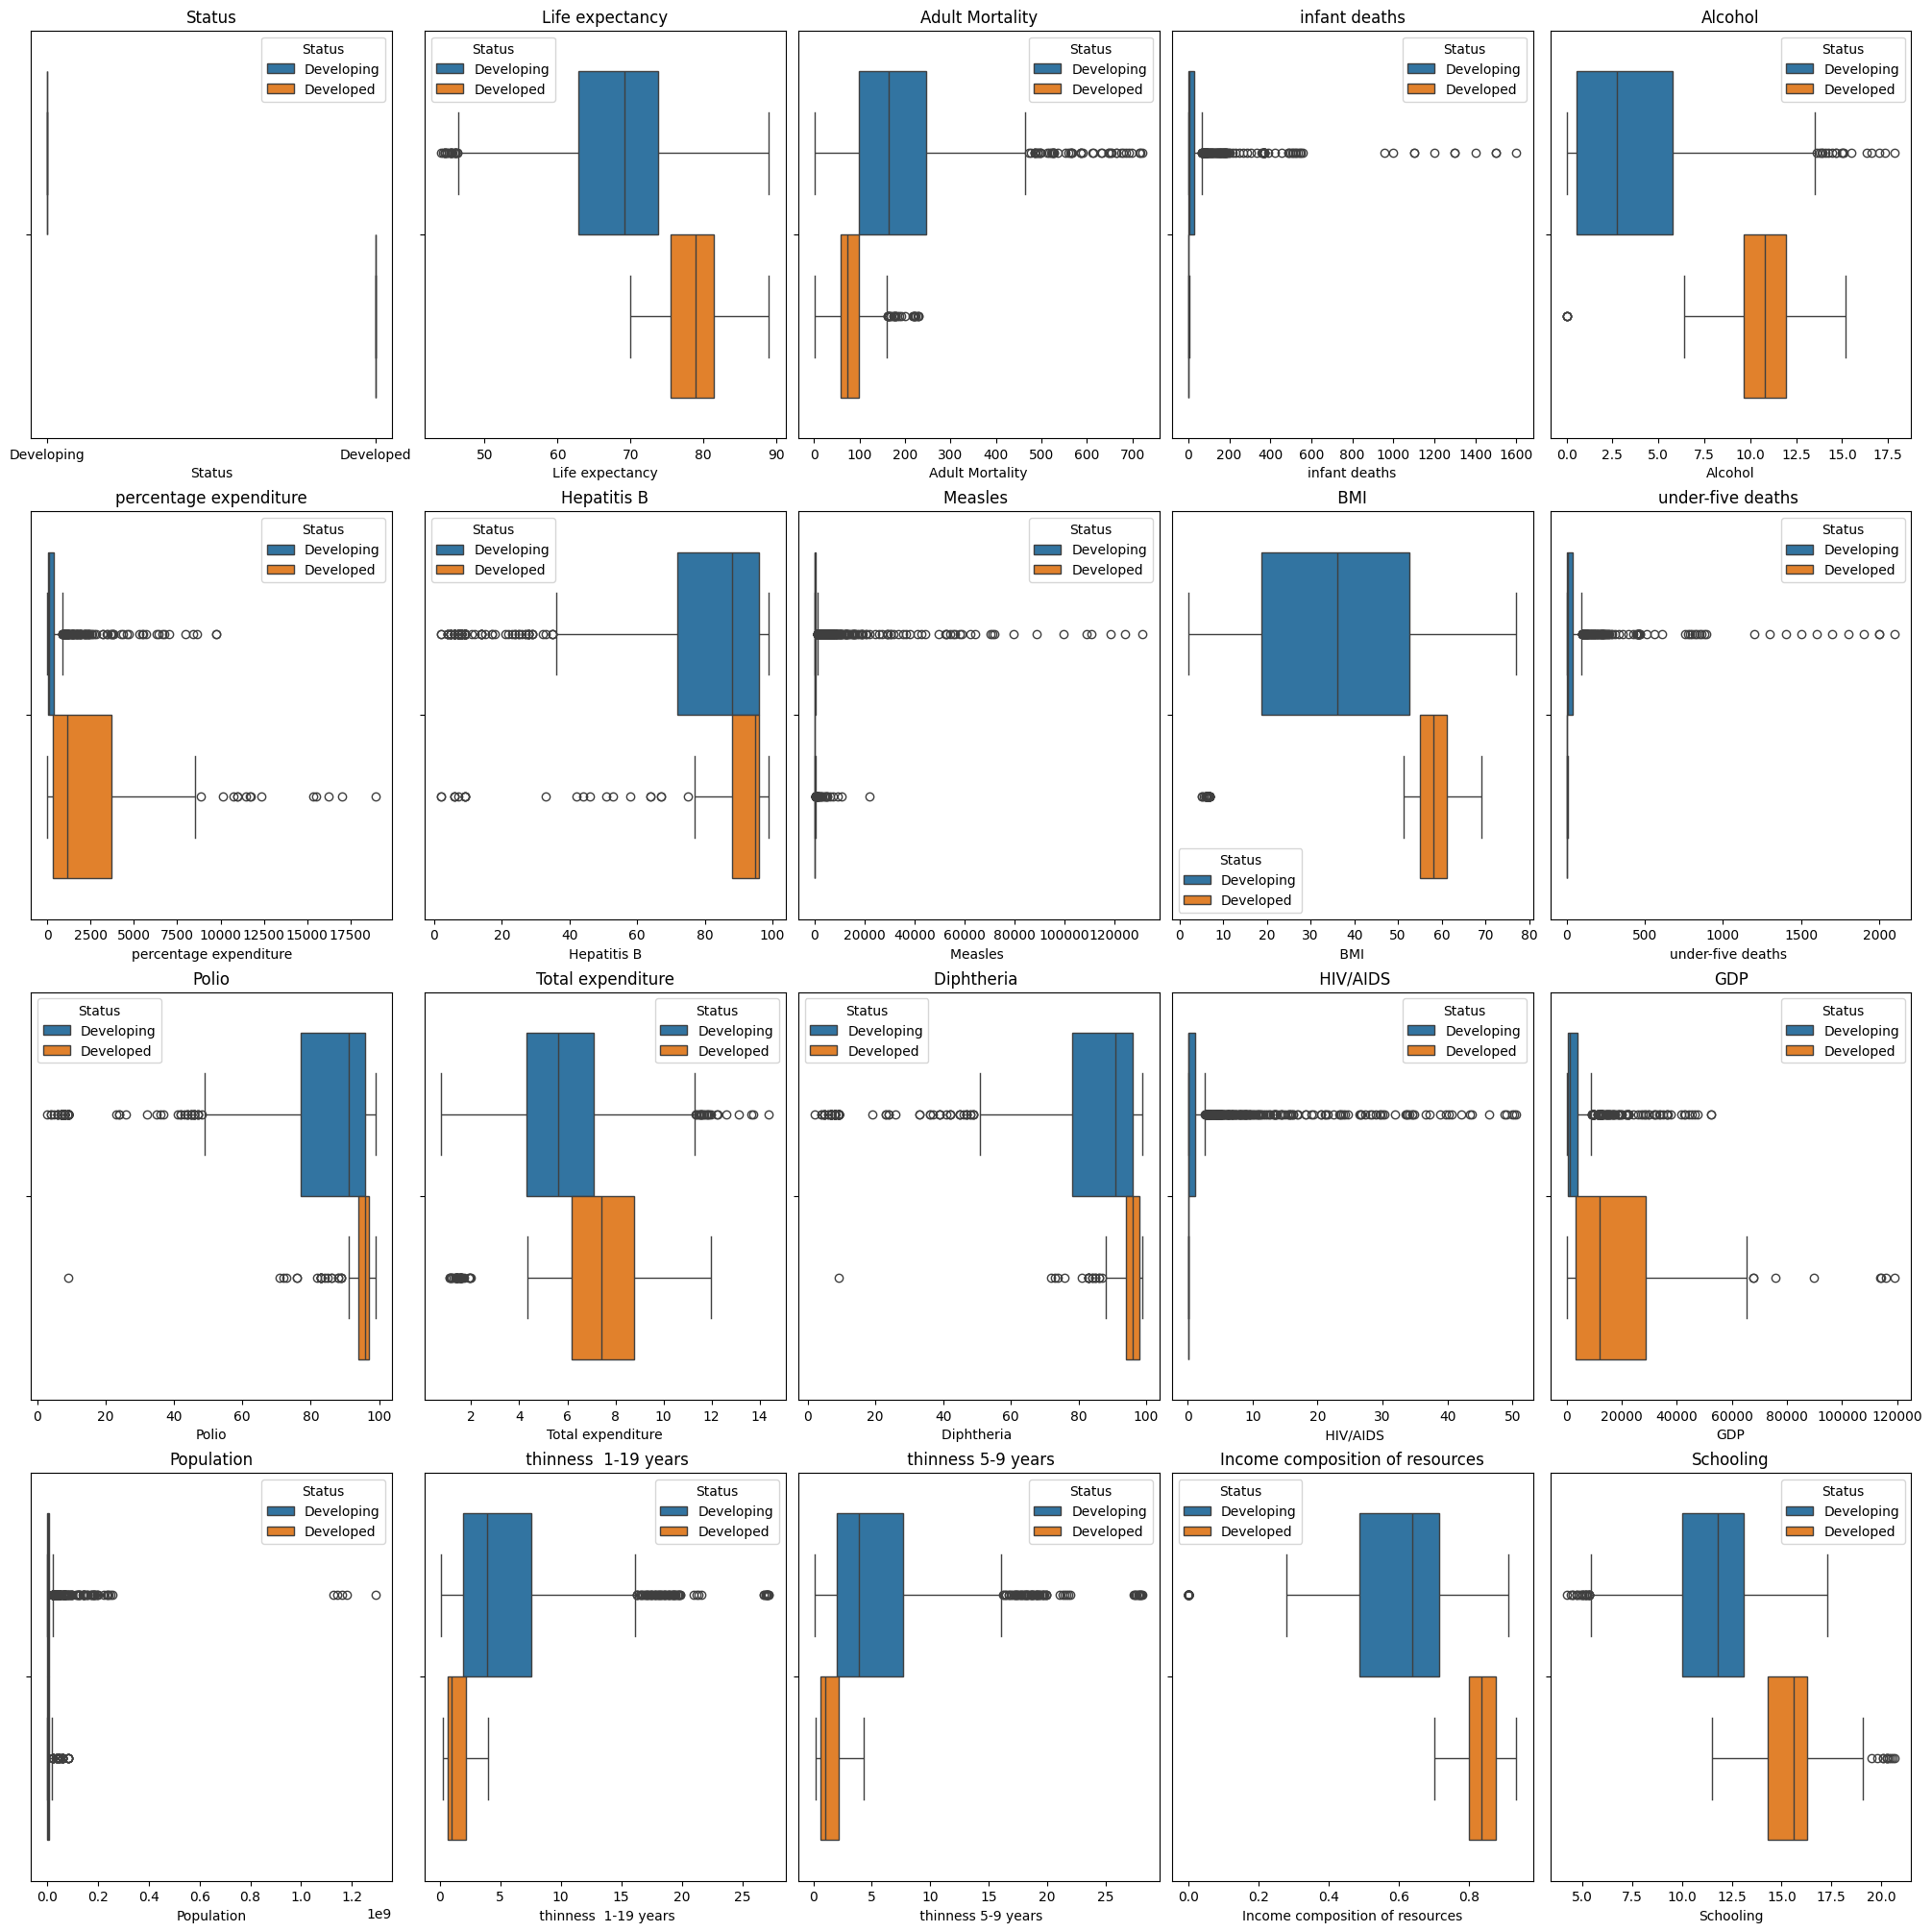

In [113]:
fig, axes = plt.subplots(4, 5, figsize=(20, 20), constrained_layout=True)
for index, column in enumerate(columns_to_plot):
    sns.boxplot(data, x = column, hue = data["Status"], ax=axes[index//5, index%5])
    axes[index//5, index%5].set_title(column)
plt.show()

<Axes: >

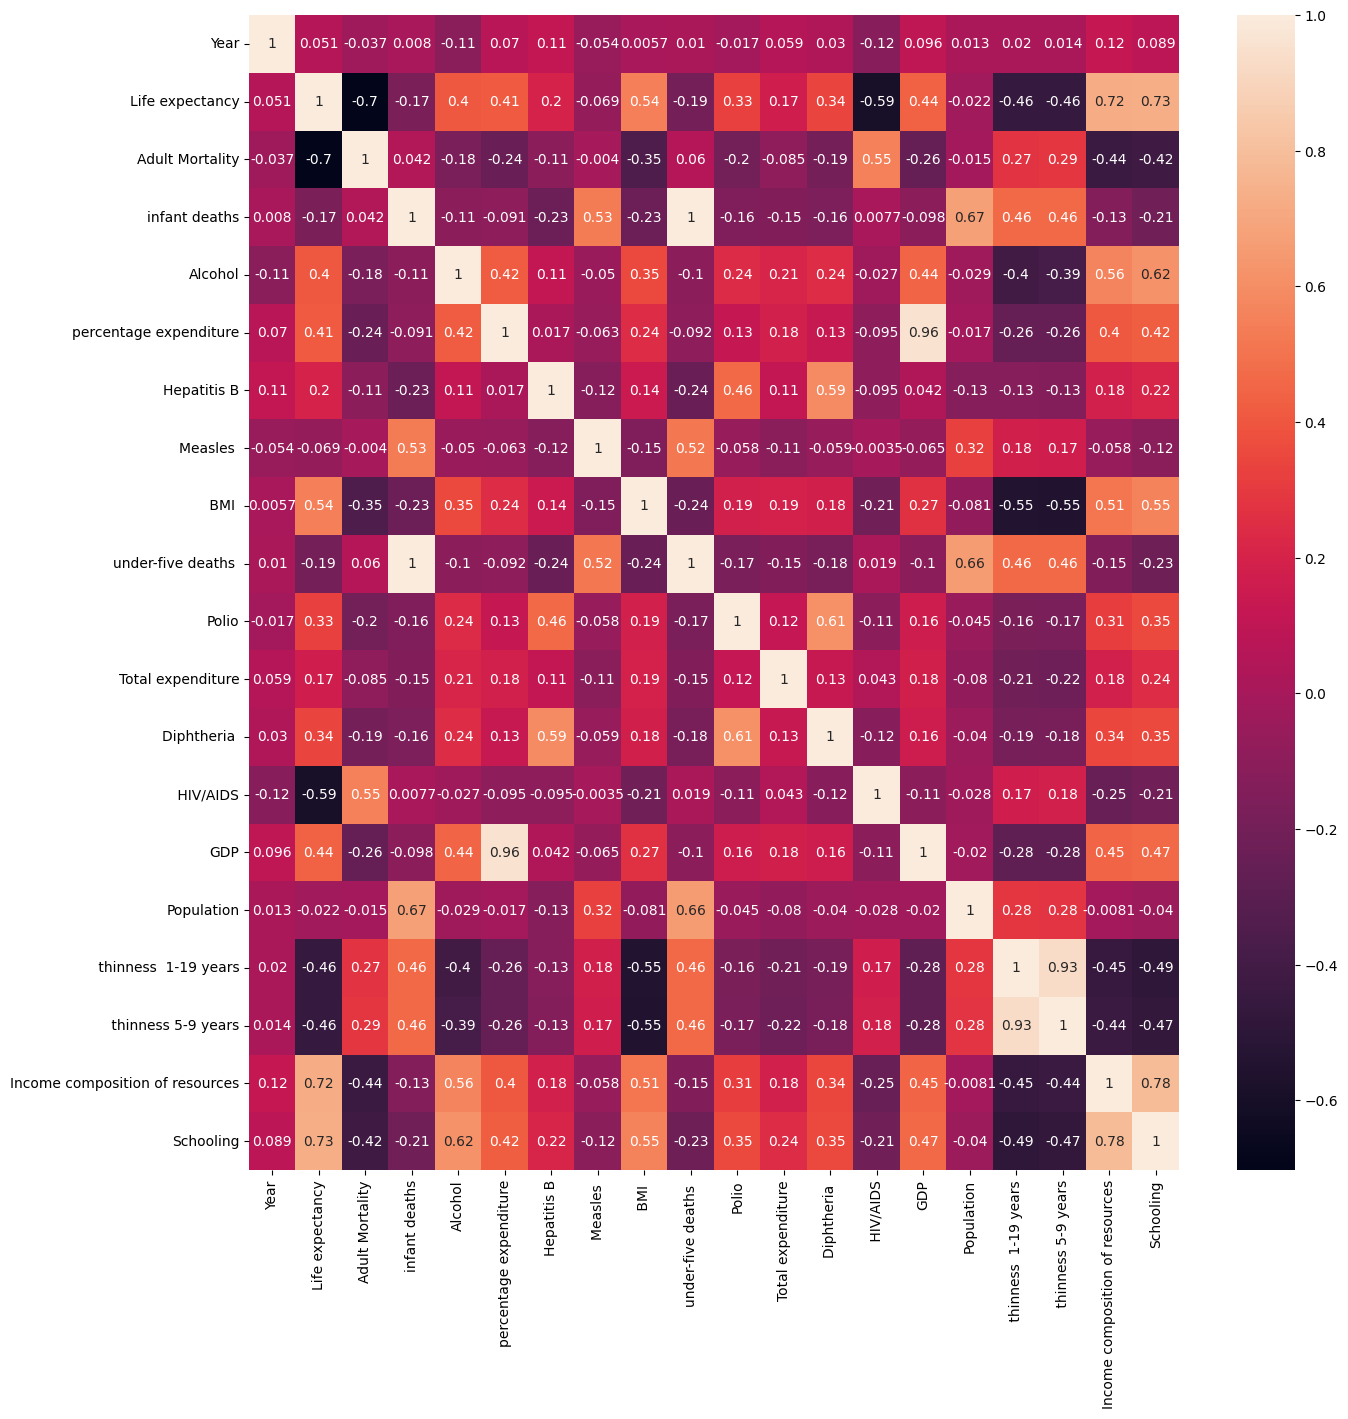

In [114]:
plt.figure(figsize=(15,15))
sns.heatmap(data.drop(columns=["Country", "Status"]).corr(), annot=True)

In [115]:
data = data.drop(columns=["Status"])
data

,Country,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,65.0,263,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,59.9,271,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,59.9,268,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,59.5,272,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,59.2,275,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,Zimbabwe,2004,44.3,723,27,4.36,0.000000,68.0,31,27.1,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2860,Zimbabwe,2003,44.5,715,26,4.06,0.000000,7.0,998,26.7,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2861,Zimbabwe,2002,44.8,73,25,4.43,0.000000,73.0,304,26.3,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2862,Zimbabwe,2001,45.3,686,25,1.72,0.000000,76.0,529,25.9,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [116]:
data_countries = data["Country"].unique()

countries_train, countries_test = train_test_split(data_countries, test_size=0.2, random_state=42)

train = data[data["Country"].isin(countries_train)]
test = data[data["Country"].isin(countries_test)]


X_train = train.drop(columns=["Life expectancy", "Country"])
X_train_countries = train["Country"]
y_train = train["Life expectancy"]

X_test = test.drop(columns=["Life expectancy", "Country"])
X_test_countries = test["Country"]
y_test = test["Life expectancy"]


In [117]:


cv = GroupKFold(n_splits=5)
splits = cv.split(X_train, y_train, groups=X_train_countries)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", ElasticNet())
])
parameters = {
    "poly__degree": [1, 2, 3],
    "model__alpha": [0.01, 0.1, 1],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}
grid_search = GridSearchCV(pipeline, parameters, cv=splits, n_jobs=5)
grid_search.fit(X_train, y_train)

display(grid_search.best_params_)
display(grid_search.best_score_)
display(grid_search.best_estimator_)

{'model__alpha': 0.1, 'model__l1_ratio': 0.9, 'poly__degree': 2}

np.float64(0.8531578545914027)

Pipeline(steps=[('scaler', StandardScaler()), ('poly', PolynomialFeatures()),
                ('model', ElasticNet(alpha=0.1, l1_ratio=0.9))])

In [118]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__l1_ratio,param_poly__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.012075,0.002029,0.003700,0.000586,0.01,0.1,1,"{'model__alpha': 0.01, 'model__l1_ratio': 0.1,...",0.811140,0.808219,0.852762,0.842229,0.776005,0.818071,0.027209,5
1,0.169918,0.019838,0.004484,0.001153,0.01,0.1,2,"{'model__alpha': 0.01, 'model__l1_ratio': 0.1,...",0.696779,0.843586,0.669462,0.801989,0.752813,0.752926,0.064413,16
2,1.566957,0.064177,0.011109,0.002082,0.01,0.1,3,"{'model__alpha': 0.01, 'model__l1_ratio': 0.1,...",-1707.531413,-0.136580,0.480058,0.524283,-1.264063,-341.585543,682.973240,27
3,0.010923,0.002124,0.004009,0.001415,0.01,0.5,1,"{'model__alpha': 0.01, 'model__l1_ratio': 0.5,...",0.815920,0.809299,0.852440,0.843632,0.776181,0.819494,0.027059,4
4,0.151467,0.038963,0.004820,0.000658,0.01,0.5,2,"{'model__alpha': 0.01, 'model__l1_ratio': 0.5,...",0.757708,0.860898,0.697978,0.804496,0.772616,0.778739,0.053695,13
5,1.361189,0.042185,0.009106,0.000757,0.01,0.5,3,"{'model__alpha': 0.01, 'model__l1_ratio': 0.5,...",-784.226992,0.392936,0.548593,0.722317,-1.994429,-156.911515,313.659310,25
6,0.017242,0.002082,0.003445,0.001059,0.01,0.9,1,"{'model__alpha': 0.01, 'model__l1_ratio': 0.9,...",0.824947,0.812528,0.852628,0.848417,0.777312,0.823167,0.027293,3
7,0.133929,0.014677,0.004939,0.001033,0.01,0.9,2,"{'model__alpha': 0.01, 'model__l1_ratio': 0.9,...",0.791904,0.871356,0.723021,0.808174,0.791015,0.797094,0.047304,10
8,1.370792,0.100796,0.011545,0.002317,0.01,0.9,3,"{'model__alpha': 0.01, 'model__l1_ratio': 0.9,...",-176.438312,0.643115,0.596464,0.811477,-1.483185,-35.174088,70.637134,24
9,0.010111,0.002853,0.003861,0.000759,0.10,0.1,1,"{'model__alpha': 0.1, 'model__l1_ratio': 0.1, ...",0.766589,0.813261,0.866503,0.832654,0.783956,0.812593,0.035343,7


In [119]:
cv_results[cv_results.rank_test_score == 1][["mean_test_score", "std_test_score"]]

,mean_test_score,std_test_score
16,0.853158,0.035162


## Metrics

In [120]:
pipeline = grid_search.best_estimator_
y_pred = pipeline.predict(X_test)
r2 = pipeline.score(X_test, y_test)
r = np.sqrt(r2)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R2: {r2}")
print(f"Pearson (r): {r}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

R2: 0.8511344067568716
Pearson (r): 0.9225694590419041
MSE: 9.562622099606495
RMSE: 3.0923489614864774


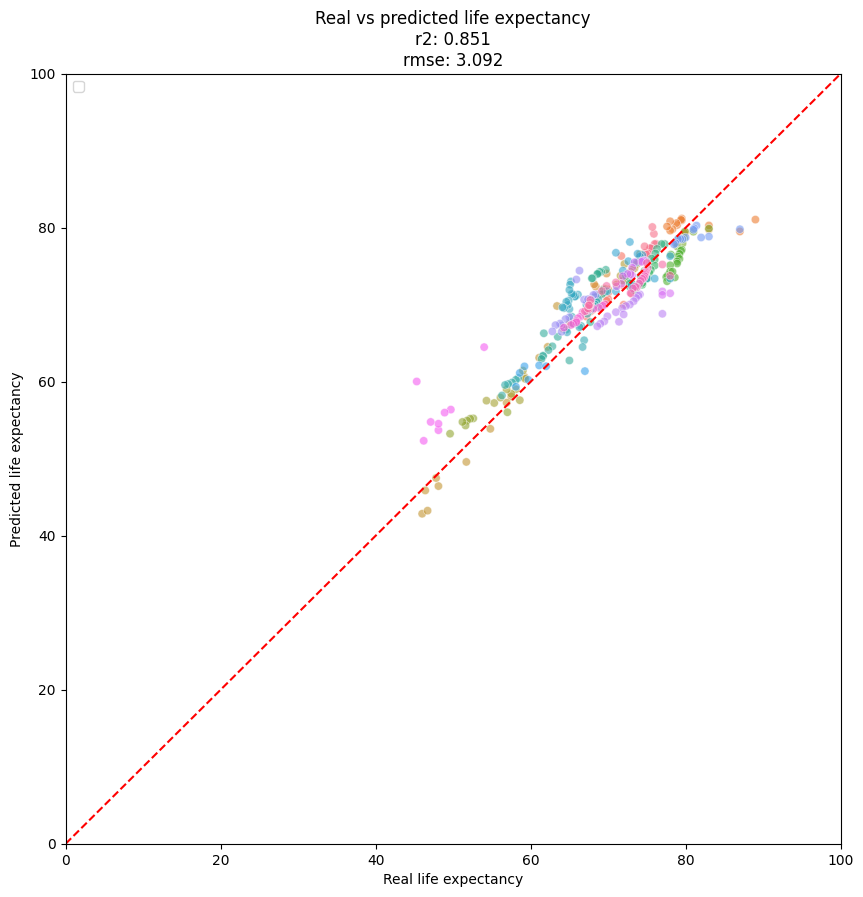

In [121]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.scatterplot(x = y_test, y = y_pred, alpha=0.6, hue=X_test_countries)
ax.set_xlabel("Real life expectancy")
ax.set_ylabel("Predicted life expectancy")
ax.set_title(f"Real vs predicted life expectancy\nr2: {round(r2, 3)}\nrmse: {round(rmse, 3)}")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.plot([0, 100], [0, 100], "--", color="red")
ax.legend([])
plt.show()

## Coefficients analysis 

In [122]:
coefs = pd.DataFrame(pipeline.named_steps["model"].sparse_coef_.toarray()).T
coefs = coefs.rename(columns={0: "coef"})
coefs["feature_names"] = pipeline.named_steps["poly"].get_feature_names_out(
    input_features = X_train.columns)

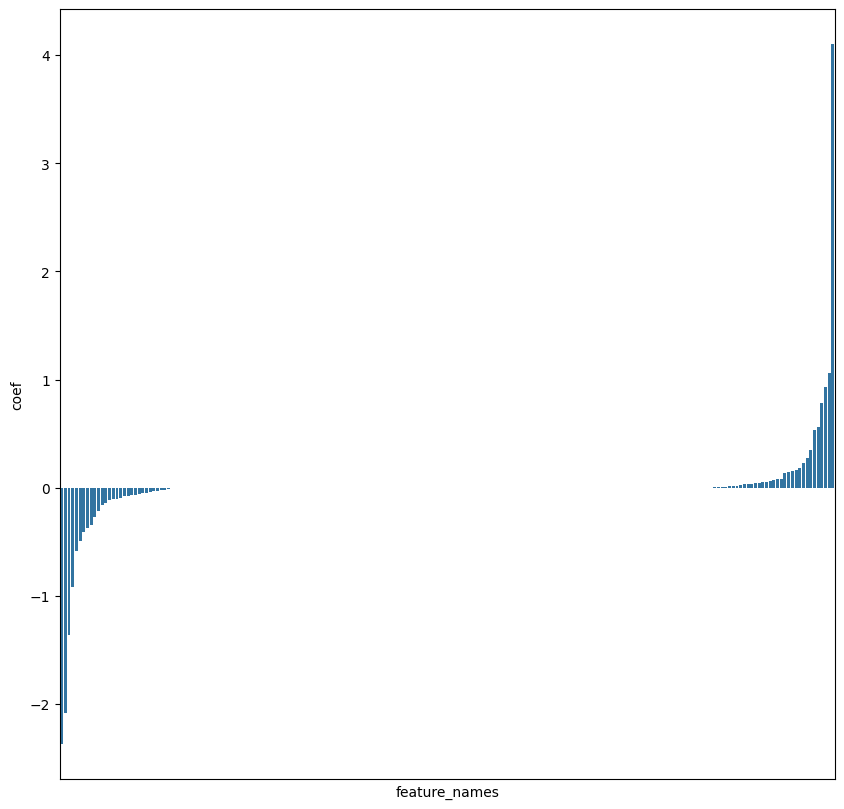

In [123]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.barplot(coefs.sort_values(by="coef"), x = "feature_names", y = "coef", axes=ax)
ax.set_xticks([])
plt.show()

In [124]:
coefs["abs_coef"] = coefs.coef.abs()
most_important = coefs.sort_values(by="abs_coef", ascending=False)[:20]

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_15508\3555459872.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(most_important.feature_names, rotation=90)


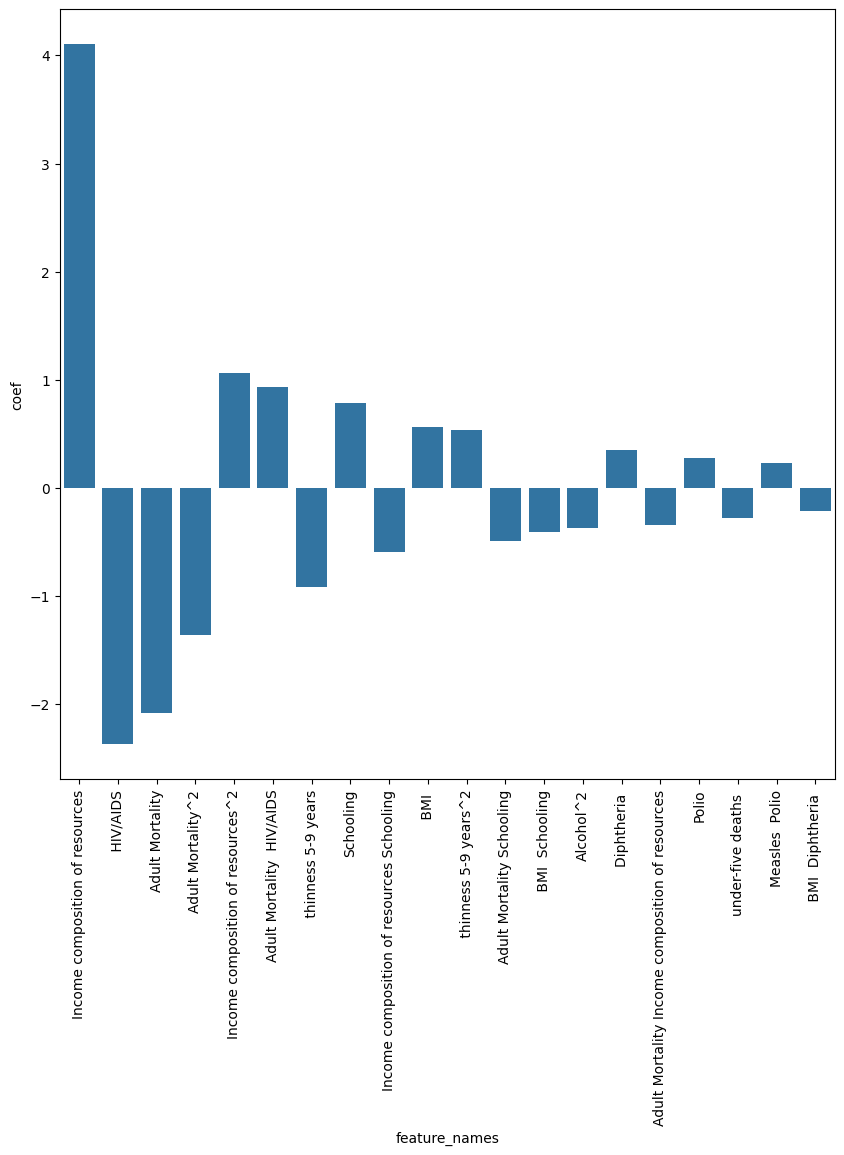

In [125]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.barplot(most_important, x = "feature_names", y = "coef", axes=ax)
ax.set_xticklabels(most_important.feature_names, rotation=90)
plt.show()